In [1]:
import tfswin

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tfswin import SwinTransformerTiny224, preprocess_input
import matplotlib.pyplot as plt

In [3]:
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.cifar10.load_data()

In [4]:
num_classes = 100
inputs = layers.Input(shape = (32,32,3), dtype = 'uint8')
outputs = layers.Lambda(preprocess_input)(inputs)
outputs = SwinTransformerTiny224(include_top = False)(outputs)
outputs = layers.Dense(num_classes, activation = 'softmax')(outputs)
swin = models.Model(inputs = inputs, outputs = outputs)

In [5]:
optimizer = tf.keras.optimizers.Adam()

swin.compile(
    optimizer = optimizer,
    loss = 'sparse_categorical_crossentropy',
    metrics = [tf.keras.metrics.SparseTopKCategoricalAccuracy(1, name = 'accuracy'),
               tf.keras.metrics.SparseTopKCategoricalAccuracy(k = 5, name = 'top-5-accuracy')]
)

In [6]:
history = swin.fit(x = train_x,
                   y = train_y,
                   batch_size = 129,
                   epochs = 10,
                   validation_split = 0.2)

Epoch 1/10

311/311 [==============================] - 128s 371ms/step - loss: 1.3195 - accuracy: 0.5296 - top-5-accuracy: 0.9127 - val_loss: 1.0395 - val_accuracy: 0.6553 - val_top-5-accuracy: 0.9693
Epoch 2/10
311/311 [==============================] - 116s 374ms/step - loss: 0.6950 - accuracy: 0.7611 - top-5-accuracy: 0.9862 - val_loss: 0.6924 - val_accuracy: 0.7747 - val_top-5-accuracy: 0.9864
Epoch 3/10
311/311 [==============================] - 115s 369ms/step - loss: 0.5294 - accuracy: 0.8205 - top-5-accuracy: 0.9928 - val_loss: 0.5826 - val_accuracy: 0.8001 - val_top-5-accuracy: 0.9891
Epoch 4/10
311/311 [==============================] - 115s 368ms/step - loss: 0.4076 - accuracy: 0.8614 - top-5-accuracy: 0.9955 - val_loss: 0.6530 - val_accuracy: 0.7971 - val_top-5-accuracy: 0.9880
Epoch 5/10
311/311 [==============================] - 115s 370ms/step - loss: 0.3470 - accuracy: 0.8801 - top-5-accuracy: 0.9973 - val_loss: 0.6956 - val_accuracy: 0.7829 - val_top-5-accuracy: 0.9877

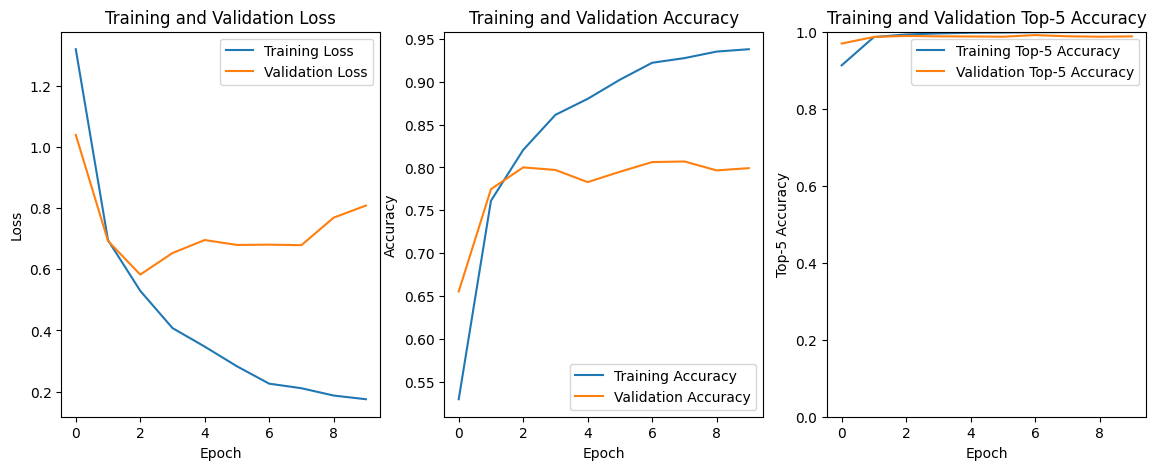

In [9]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['top-5-accuracy'], label='Training Top-5 Accuracy')
plt.plot(history.history['val_top-5-accuracy'], label='Validation Top-5 Accuracy')
plt.title('Training and Validation Top-5 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Top-5 Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.show()

In [10]:
swin.evaluate(test_x, test_y)

313/313 [==============================] - 18s 58ms/step - loss: 0.8283 - accuracy: 0.8000 - top-5-accuracy: 0.9884


[0.8282746076583862, 0.800000011920929, 0.9883999824523926]